# Project 3
Alex Heyert July 17th 2026

### Multi-Class Categorical Prediction
This toy dataset looks at 178 Italian Wines made by 3 different "Cultivars" 
Lichman, M. (2013). UCI Machine Learning Repository [https://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

# 1. Imports And Data Inspection 

In [343]:
from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
from matplotlib.pyplot import axes
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import (
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M03", level="DEBUG")
log_header(LOG, "M03")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

2026-07-17 13:42:59 | INFO | M03 | === RUN START ===
2026-07-17 13:42:59 | INFO | M03 | project=M03
2026-07-17 13:42:59 | INFO | M03 | repo_dir=ml-03-classification
2026-07-17 13:42:59 | INFO | M03 | python=3.14.0
2026-07-17 13:42:59 | INFO | M03 | os=Windows 11
2026-07-17 13:42:59 | INFO | M03 | shell=powershell
2026-07-17 13:42:59 | INFO | M03 | cwd=notebooks
2026-07-17 13:42:59 | INFO | M03 | github_actions=False
2026-07-17 13:42:59 | INFO | M03 | Confirming installation:
2026-07-17 13:42:59 | INFO | M03 |   python:       3.14.0
2026-07-17 13:42:59 | INFO | M03 |   pandas:       3.0.3
2026-07-17 13:42:59 | INFO | M03 |   numpy:        2.5.1
2026-07-17 13:42:59 | INFO | M03 |   scikit-learn: 1.9.0
2026-07-17 13:42:59 | INFO | M03 |   seaborn:      0.13.2
2026-07-17 13:42:59 | INFO | M03 |   matplotlib:   3.11.0


In [344]:
# Create and inspect dataframe
df: pd.DataFrame = load_wine(as_frame=True).frame  # pyright: ignore[reportAttributeAccessIssue]
display(df.head())
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")
display(df.describe())
# count missing values
LOG.info(f"Missing values: {df.isnull().sum().sum()}")
TARGET: Final[str] = "target"

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


2026-07-17 13:42:59 | INFO | M03 | Loaded: 178 rows (instances), 14 columns


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


2026-07-17 13:42:59 | INFO | M03 | Missing values: 0


# 2. Visualize Raw Data

2026-07-17 13:42:59 | INFO | M03 | Correlation range for target variable: -0.8474975401417585 to 1.0
2026-07-17 13:42:59 | INFO | M03 | Strong correlations with target:
['alcalinity_of_ash', 'total_phenols', 'flavanoids', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']


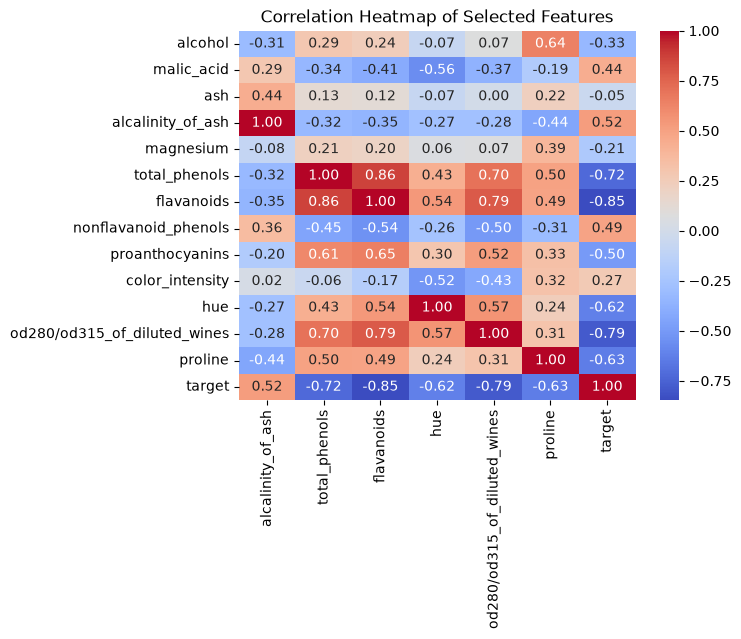

In [345]:
# Look for strong correlations between features and the target variable,
# Choose a threshold for strong correlation with by seeing what the correlation range is for the target variable.

correlations: pd.DataFrame = df.corr()
LOG.info(
    f"Correlation range for target variable: {correlations[TARGET].min()} to {correlations[TARGET].max()}"
)
# Filter correlations to only include those with a strong correlation with the target variable
strong_correlation_features: list[str] = correlations[
    abs(correlations[TARGET]) > 0.5
].index.tolist()
LOG.info(f"Strong correlations with target:\n{strong_correlation_features}")
strong_correlations: pd.DataFrame = correlations[strong_correlation_features]


sns.heatmap(strong_correlations, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Selected Features")
plt.show()

<Figure size 640x480 with 0 Axes>

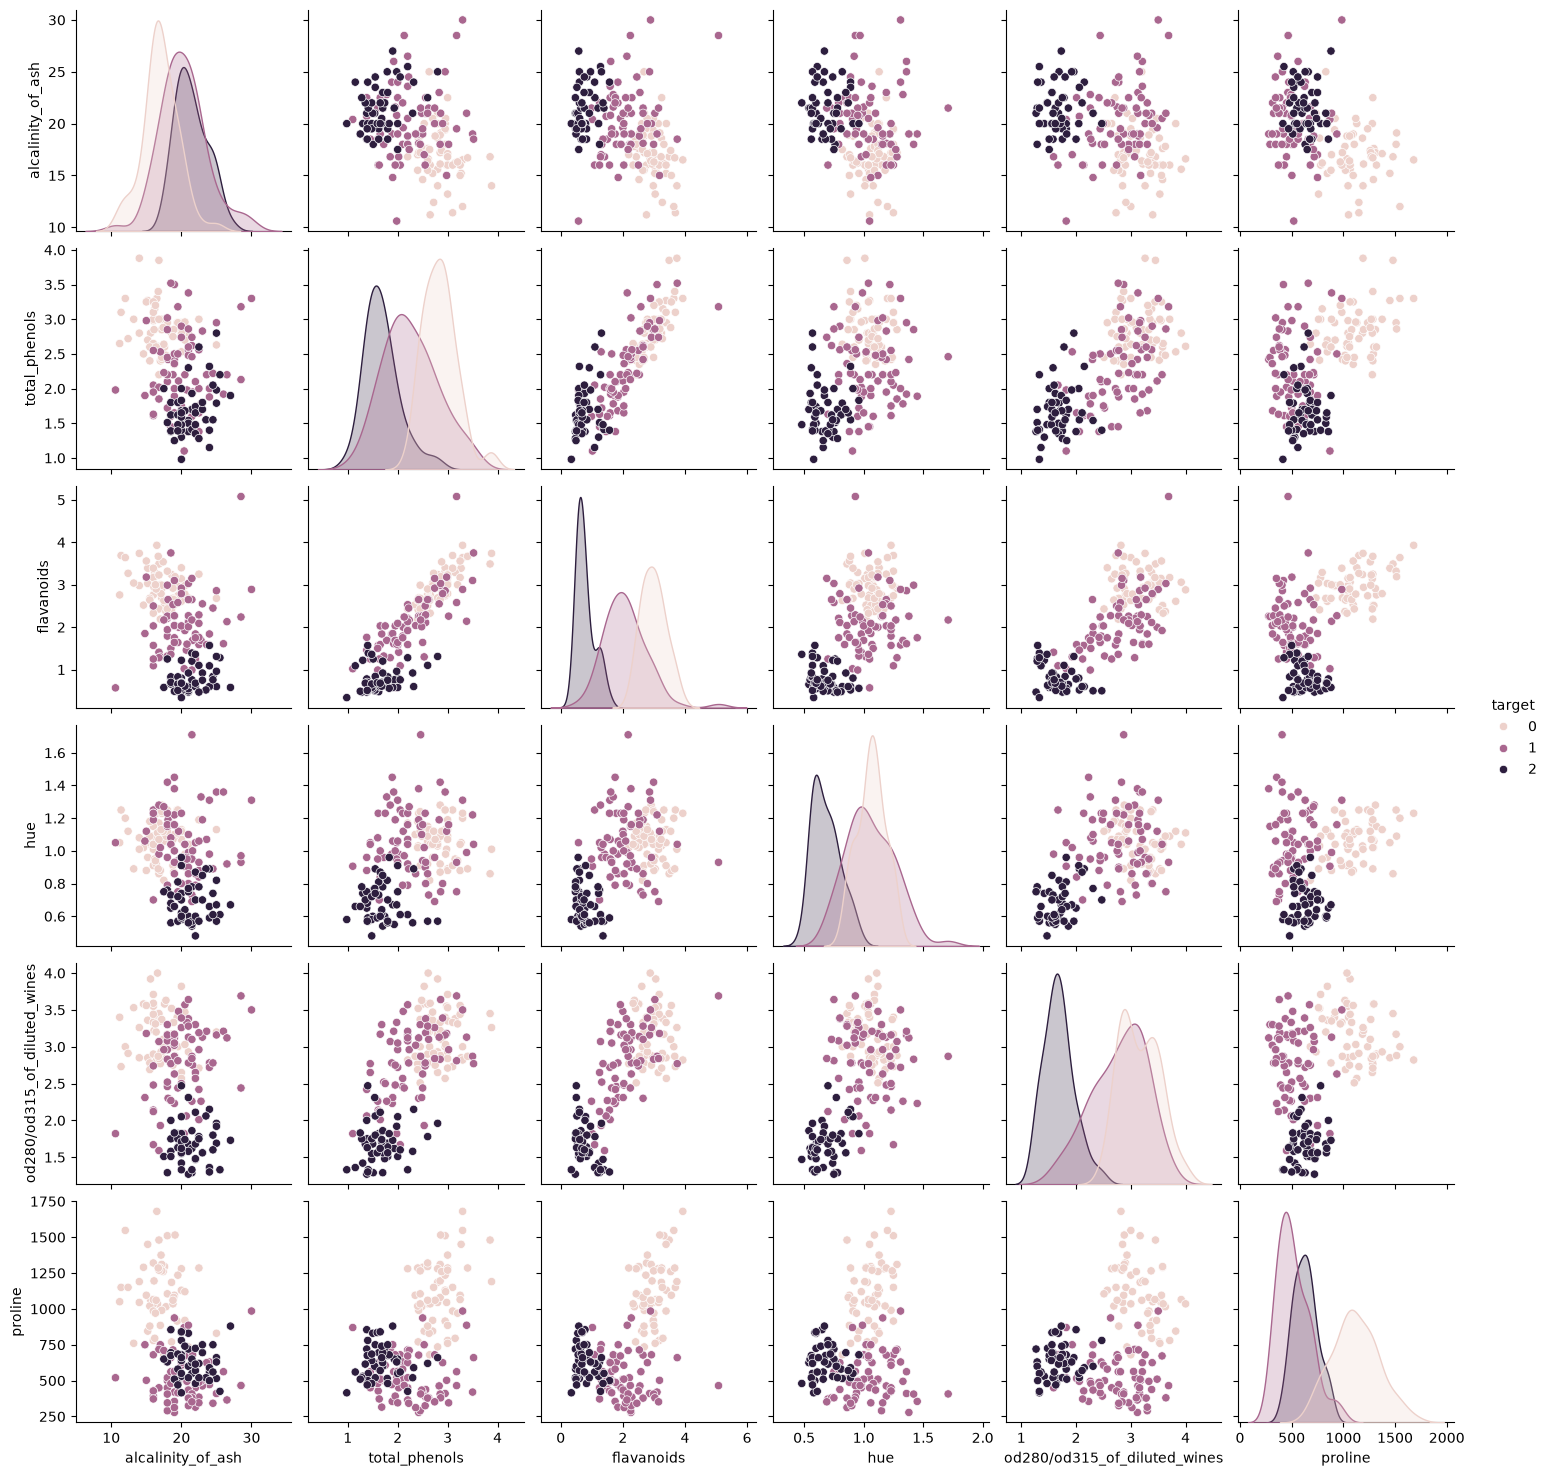

In [346]:
plt.figure()
sns.pairplot(df[strong_correlation_features], hue=TARGET)
plt.show()

# 3. Split Intro Train and Test

In [347]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""
feature_columns: list[str] = [col for col in df.columns if col != TARGET]


def train_data(
    RANDOM_STATE, feature_columns
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    X: pd.DataFrame = df[feature_columns]
    y: pd.Series = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    LOG.info(f"Train instances: {len(X_train)}")
    LOG.info(f"Test instances: {len(X_test)}")
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = train_data(RANDOM_STATE, feature_columns)

2026-07-17 13:43:07 | INFO | M03 | Train instances: 142
2026-07-17 13:43:07 | INFO | M03 | Test instances: 36


# 4. Fit a Classifier

In [348]:
def fit_decision_tree(X_trainP, y_trainP) -> DecisionTreeClassifier:
    """
    Fit a decision-tree classifier on the training data.
    WHY: create -> .fit() -> .predict()
    is the same pattern for every scikit-learn estimator.
    Learning it once carries to every later model.
    """

    # MAX DEPTH is one tunable parameter of the model.

    # For a decision tree, max_depth controls complexity:
    # - shallow underfits
    # - deep overfits

    # Section 6 shows the effect; we must choose and defend a value.
    # This is typically part of the interative process of model development.
    MAX_DEPTH: Final[int] = 3

    LOG.info(f"Fitting DecisionTreeClassifier(max_depth={MAX_DEPTH})")

    # create a DecisionTreeClassifier with the chosen max_depth and random_state
    model = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=RANDOM_STATE)

    # fit the model on the training data
    model.fit(X_trainP, y_trainP)
    return model


decision_tree_model = fit_decision_tree(X_train, y_train)

2026-07-17 13:43:07 | INFO | M03 | Fitting DecisionTreeClassifier(max_depth=3)


# 5. Evaluate Model

2026-07-17 13:43:07 | INFO | M03 | Test accuracy: 0.944
2026-07-17 13:43:07 | INFO | M03 | Per-class precision / recall / F1:
2026-07-17 13:43:07 | DEBUG | M03 | 
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36

2026-07-17 13:43:07 | INFO | M03 | Showing confusion matrix (rows = actual, cols = predicted)


<Figure size 640x480 with 0 Axes>

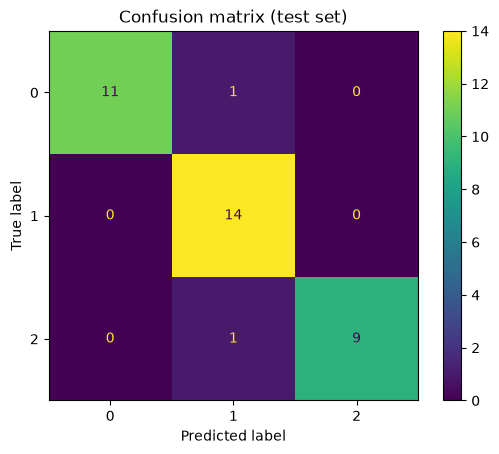

In [349]:
# === Section 5. Evaluate the Model ===

"""Score the model on held-out data and show a confusion matrix.

WHY: A single accuracy number hides which classes get confused.
The report adds precision/recall/F1 per class;
the confusion matrix shows the actual vs. predicted counts.
Read them together.

Code only reports numbers.

It does NOT declare the model good enough.
Whether a model is good enough depends on what a mistake costs
in this specific problem,
which requires analyst judgment.
"""

y_pred: np.ndarray = decision_tree_model.predict(X_test)

# The built in sklearn accuracy_score() function
# returns a numpy Float,
# which is not the same as a native Python float.
# call float() to convert it to a native Python float for better compatibility with other code and libraries.
test_acc: float = float(accuracy_score(y_test, y_pred))
LOG.info(f"Test accuracy: {test_acc:.3f}")

LOG.info("Per-class precision / recall / F1:")
LOG.debug(f"\n{classification_report(y_test, y_pred)}")

LOG.info("Showing confusion matrix (rows = actual, cols = predicted)")

# start a figure
plt.figure()

# create the confusion matrix display
ConfusionMatrixDisplay.from_estimator(decision_tree_model, X_test, y_test)

# set the title
plt.title("Confusion matrix (test set)")

# show the plot
plt.show()

# 6. Parameter Tuning

2026-07-17 13:43:08 | DEBUG | M03 |   depth= 1  train=0.662  test=0.583


2026-07-17 13:43:08 | DEBUG | M03 |   depth= 2  train=0.937  test=0.861
2026-07-17 13:43:08 | DEBUG | M03 |   depth= 3  train=0.993  test=0.944
2026-07-17 13:43:08 | DEBUG | M03 |   depth= 4  train=1.000  test=0.944
2026-07-17 13:43:08 | DEBUG | M03 |   depth= 5  train=1.000  test=0.944
2026-07-17 13:43:08 | DEBUG | M03 |   depth= 6  train=1.000  test=0.944
2026-07-17 13:43:08 | DEBUG | M03 |   depth= 7  train=1.000  test=0.944
2026-07-17 13:43:08 | DEBUG | M03 |   depth= 8  train=1.000  test=0.944
2026-07-17 13:43:08 | DEBUG | M03 |   depth= 9  train=1.000  test=0.944
2026-07-17 13:43:08 | DEBUG | M03 |   depth=10  train=1.000  test=0.944
2026-07-17 13:43:08 | DEBUG | M03 |   depth=11  train=1.000  test=0.944
2026-07-17 13:43:08 | DEBUG | M03 |   depth=12  train=1.000  test=0.944


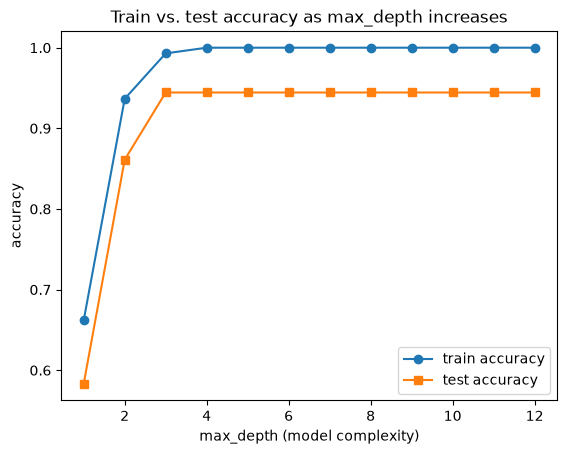

In [350]:
# === Section 6. How Parameter Selection Affects Performance ===

# THIS IS DATA SET DEPENDENT and ANALYST CHOICE.

MAX_SWEEP: Final[int] = 12

# Declare lists to hold the depths and corresponding train/test scores.
depths: list[int] = list(range(1, MAX_SWEEP + 1))
train_scores: list[float] = []
test_scores: list[float] = []

for depth in depths:
    # create and fit a DecisionTreeClassifier with the current depth and random_state
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)

    acc_score_train = accuracy_score(y_train, m.predict(X_train))
    acc_score_test = accuracy_score(y_test, m.predict(X_test))

    # Use float() to convert from numpy Float to native Python float for better compatibility with other code and libraries.
    train_scores.append(float(acc_score_train))
    test_scores.append(float(acc_score_test))

    LOG.debug(
        f"  depth={depth:2d}  train={train_scores[-1]:.3f}  test={test_scores[-1]:.3f}"
    )

# start a new figure
plt.figure()

# plot the train and test scores against the depths
plt.plot(depths, train_scores, marker="o", label="train accuracy")
plt.plot(depths, test_scores, marker="s", label="test accuracy")

# label the axes and add a title and legend
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.title("Train vs. test accuracy as max_depth increases")
plt.legend()

# show the plot
plt.show()

# New Model Choice

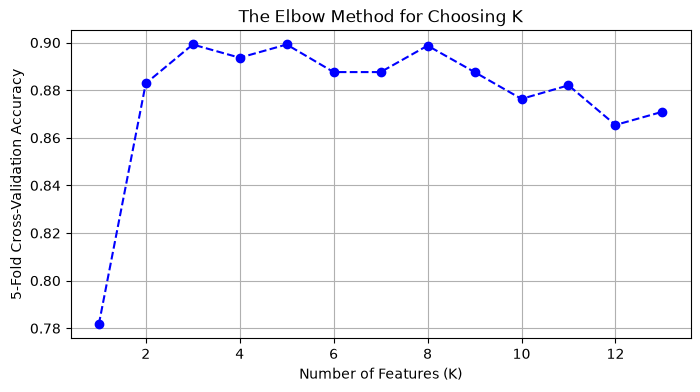

In [351]:
new_X = df[feature_columns]
new_Y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    new_X, new_Y, test_size=0.20, random_state=42, stratify=new_Y
)

k_values = range(1, 14)  # from 1 to 13 features
cv_scores = []

for k in k_values:
    # Select top K features
    selector = SelectKBest(score_func=mutual_info_classif, k=k)
    X_selected = selector.fit_transform(new_X, new_Y)

    # Check accuracy using a fast baseline classifier
    scores = cross_val_score(
        decision_tree_model, X_selected, new_Y, cv=5, scoring='accuracy'
    )
    cv_scores.append(scores.mean())

# 3. Plot K vs Cross-Validated Accuracy
plt.figure(figsize=(8, 4))
plt.plot(k_values, cv_scores, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Features (K)')
plt.ylabel('5-Fold Cross-Validation Accuracy')
plt.title('The Elbow Method for Choosing K')
plt.grid(True)
plt.show()

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Selected features: Index(['alcohol', 'flavanoids', 'color_intensity',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='str')
All-feature accuracy: 0.9722222222222222
Reduced-feature accuracy: 1.0


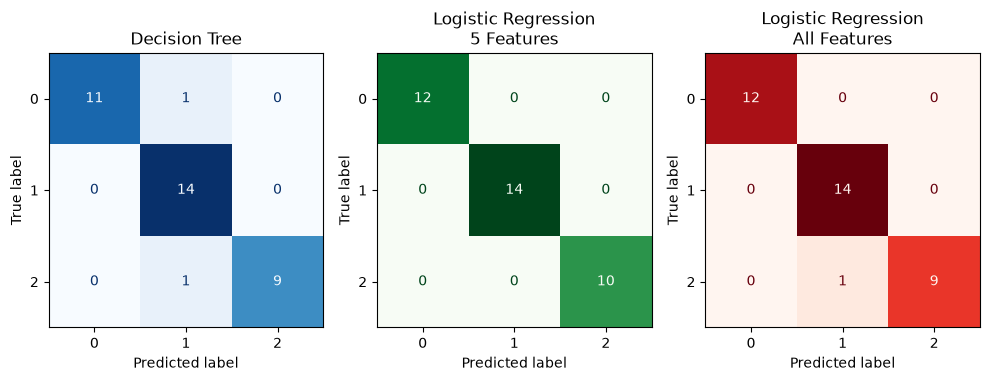

In [ ]:
# Split before feature selection to avoid data leakage
logistic_selected = make_pipeline(
    SelectKBest(score_func=f_classif, k=5),
    StandardScaler(),
    LogisticRegression(max_iter=1000),
)

logistic_selected.fit(X_train, y_train)
y_pred = logistic_selected.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


selector = logistic_selected.named_steps["selectkbest"]
selected_features = new_X.columns[selector.get_support()]

print("Selected features:", selected_features)

logistic_all = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

logistic_all.fit(X_train, y_train)
baseline_pred = logistic_all.predict(X_test)

print("All-feature accuracy:", accuracy_score(y_test, baseline_pred))
print("Reduced-feature accuracy:", accuracy_score(y_test, y_pred))

fig, axes = plt.subplots(1, 3, figsize=(10, 4))  # noqa: F811

ConfusionMatrixDisplay.from_estimator(
    decision_tree_model, X_test, y_test, ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Decision Tree")

ConfusionMatrixDisplay.from_estimator(
    logistic_selected, X_test, y_test, ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Logistic Regression\n5 Features")

ConfusionMatrixDisplay.from_estimator(
    logistic_all, X_test, y_test, ax=axes[2], cmap="Reds", colorbar=False
)
axes[2].set_title("Logistic Regression\nAll Features")

plt.tight_layout()
plt.show()

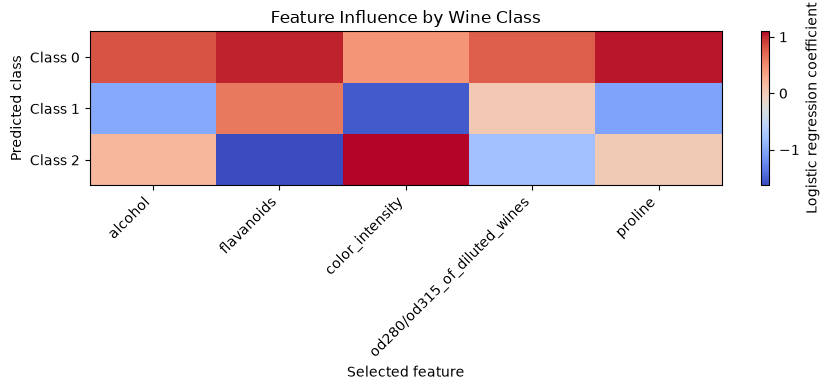

In [353]:
classifier = logistic_selected.named_steps["logisticregression"]

selected_features = new_X.columns[selector.get_support()]
coefficients = classifier.coef_

plt.figure(figsize=(9, 4))

plt.imshow(coefficients, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Logistic regression coefficient")

plt.xticks(range(len(selected_features)), selected_features, rotation=45, ha="right")

plt.yticks(range(len(classifier.classes_)), [f"Class {c}" for c in classifier.classes_])

plt.title("Feature Influence by Wine Class")
plt.xlabel("Selected feature")
plt.ylabel("Predicted class")
plt.tight_layout()
plt.show()